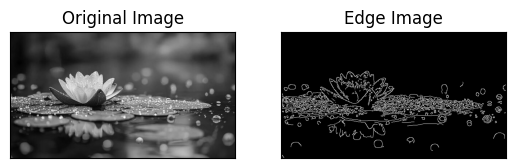

In [1]:
import cv2
import numpy as np 
from matplotlib import pyplot as plt
img = cv2.imread('image.jpg', 0)
edges =cv2.Canny(img,100,200)
plt.subplot(121), plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap ='gray') 
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

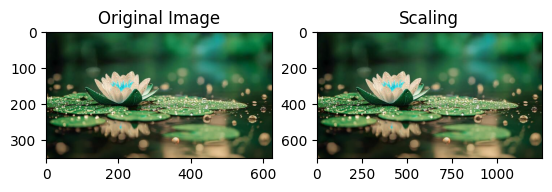

In [4]:
img = cv2.imread('image.jpg')
# res= cv2.resize(img, None, fx=2, fy=2, interpolation= cv2.INTER_CUBIC)
height, width= img.shape[:2]
res= cv2.resize(img, (2*width, 2*height), interpolation= cv2.INTER_CUBIC)
plt.subplot(121),plt.imshow(img), plt.title("Original Image")
# plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(res), plt.title("Scaling")
# plt.xticks([]), plt.yticks([])
plt.show()


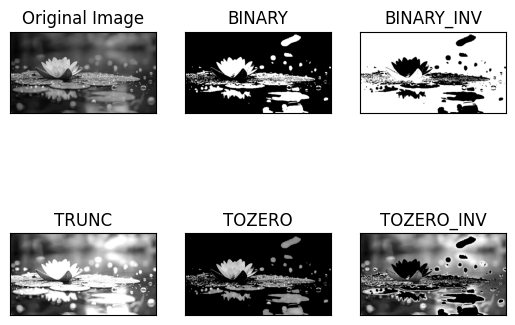

In [5]:
img = cv2.imread("image.jpg", 0)
ret,thresh1 =cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)
ret,thresh2 =cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)
ret,thresh3 =cv2.threshold(img, 128, 255, cv2.THRESH_TRUNC)
ret,thresh4 =cv2.threshold(img, 128, 255, cv2.THRESH_TOZERO)
ret,thresh5 =cv2.threshold(img, 128, 255, cv2.THRESH_TOZERO_INV)

title= ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images= [img, thresh1,thresh2, thresh3,thresh4,thresh5]

for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(title[i])
    plt.xticks([]),plt.yticks([])

plt.show()

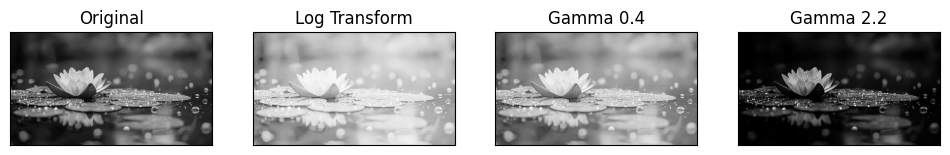

In [6]:
# log and gamma transformations
# use existing img (grayscale if cell 2 was run); convert if it's BGR
if img.ndim == 3:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
else:
    img_gray = img

# Log transform
img_float = img_gray.astype(np.float32)
log_image = np.log1p(img_float)
log_image = (log_image * (255.0 / log_image.max())).astype(np.uint8)

# Gamma transforms (example gamma values)
gammas = [0.4, 2.2]
gamma_images = []
for g in gammas:
    gamma_corr = ((img_float / 255.0) ** g) * 255.0
    gamma_images.append(gamma_corr.astype(np.uint8))

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1, 4, 1), plt.imshow(img_gray, cmap='gray'), plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 4, 2), plt.imshow(log_image, cmap='gray'), plt.title('Log Transform'), plt.xticks([]), plt.yticks([])
for idx, g_img in enumerate(gamma_images, start=3):
    plt.subplot(1, 4, idx), plt.imshow(g_img, cmap='gray'), plt.title(f'Gamma {gammas[idx-3]}'), plt.xticks([]), plt.yticks([])
plt.show()